# This notebook loads and inspects a 2 dimensional timeseries
## It visualizes the timeseries through plots, calculates autodifference, calculates power spectrum
### Example timeseries shown is real data recorded by a RPG-FFTS spectrometer, but any similar dataset can be used

**Loading necessary packages. Please install packages if not present.**

In [1]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

**Loading the 2D timeseries file, real data from a noise diode passing through a cicuit recorded by a FFT spectrometer**

In [2]:
file=open('RPGFFTSchanA.spec','r')

**Loading data into numpy array - has specific steps based on datafile - need to adjust based on one's requirements**

In [3]:
# reading in full data
a0 = file.read()

# splitting data for each timestamp
s0 = np.array(a0.split('*')[1:])

# looping over each timestamp row to split data for each channel - and write all of it into 2-d array
dum = np.array(s0[0].split('\n'))
spec = np.zeros((s0.shape[0]-1,dum.shape[0]-2))
for i in range(s0.shape[0]-1):
    spec[i] = np.array(s0[i].split('\n')[1:dum.shape[0]-1])

# converting data type from float 64 to int 32
spec.astype(np.int32)

# calibrating to physical units (milli watts)
ts = 0.1
chans = 8192
spec=pow(10,(10.00405331*np.log10(spec/ts)-147.24685047)/10)/chans

/var/folders/_8/scf0b0g13g9f9vr2vtljc8480000gn/T/ipykernel_67304/3244883979.py:14: RuntimeWarning: invalid value encountered in cast
  spec.astype(np.int32)


**Plotting data as a wterfall plot**

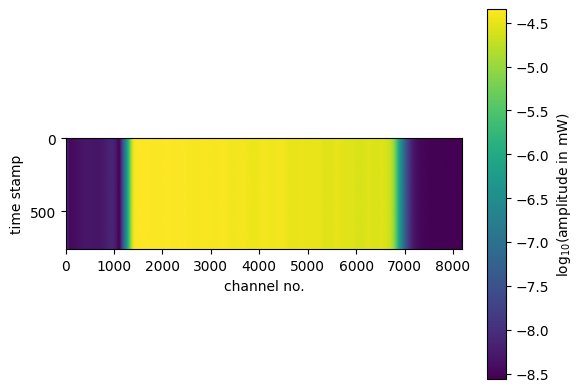

In [4]:
# new array with logarithmic values - can choose channels to look at here
plspec=np.log10(spec)

# plotting the data
plt.figure()
plt.xlabel('channel no.')
plt.ylabel('time stamp')
plt.imshow(plspec,aspect=3,interpolation='nearest')
cbar=plt.colorbar()
cbar.set_label('log$_{10}$(amplitude in mW)')
plt.show()

**Plotting 1D data along 'channels' axis for individual equidistant points along 'time' axis**

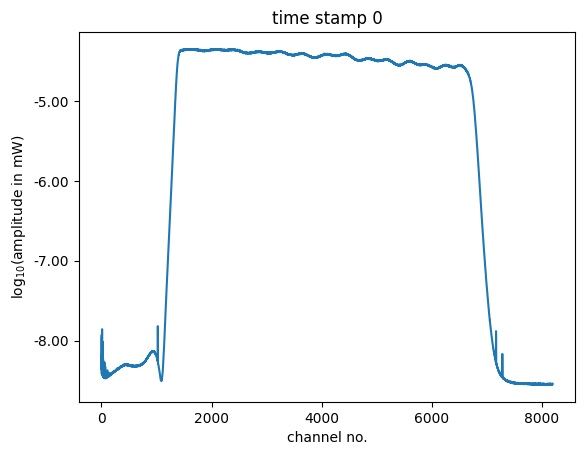

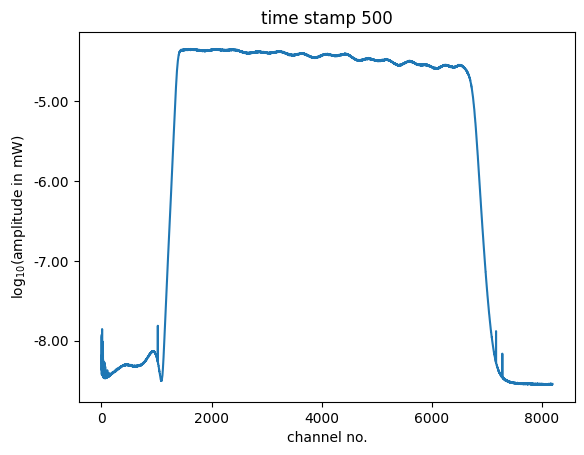

In [5]:
n = 500

i = 0
while(i<spec.shape[0]):
    plt.figure()
    plsp = plspec[i,:]
    plt.title('time stamp '+str(i))
    plt.xlabel('channel no.')
    plt.ylabel('log$_{10}$(amplitude in mW)')
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    plt.plot(plsp)
    plt.show()
    i += n

plt.show()

**Plotting 1D data along 'time' axis - the actual timeseries, and its power spectrum - for an individual 'channel**

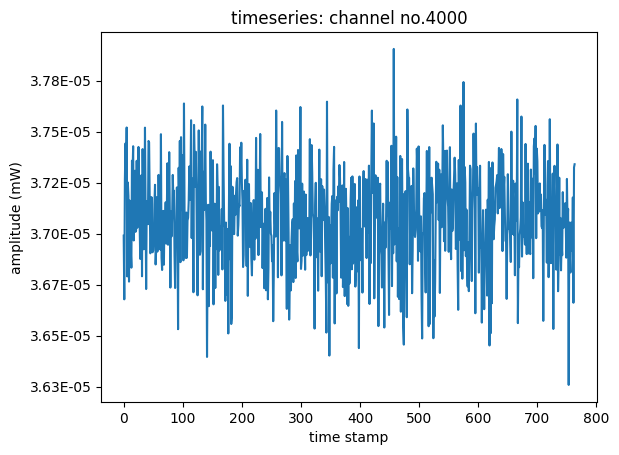

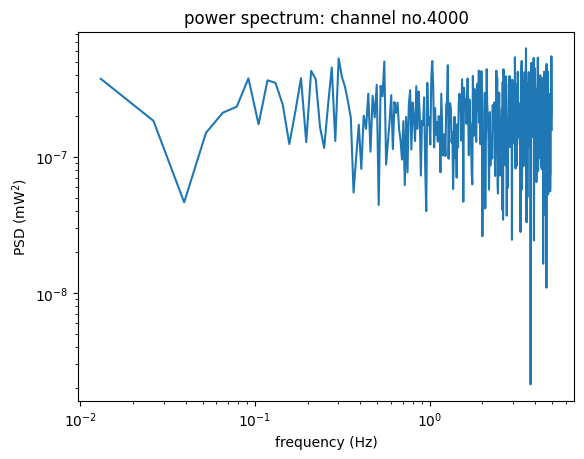

In [6]:
chan = 4000

plsp = spec[:,chan]

plt.figure()
plt.title('timeseries: channel no.'+str(chan))
plt.xlabel('time stamp')
plt.ylabel('amplitude (mW)')
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2E'))
plt.plot(plsp)
plt.show()

Psp = np.absolute(np.fft.rfft(plsp,norm='ortho'))[1:]
fsp = np.fft.rfftfreq(plsp.shape[0],ts)[1:]

plt.figure()
plt.title('power spectrum: channel no.'+str(chan))
plt.xlabel('frequency (Hz)')
plt.ylabel('PSD (mW$^2$)')
plt.semilogx()
plt.semilogy()
plt.plot(fsp,Psp)
plt.show()

**Plotting 1D data along 'time' axis - the actual timeseries - averaged over a range of 'channels**

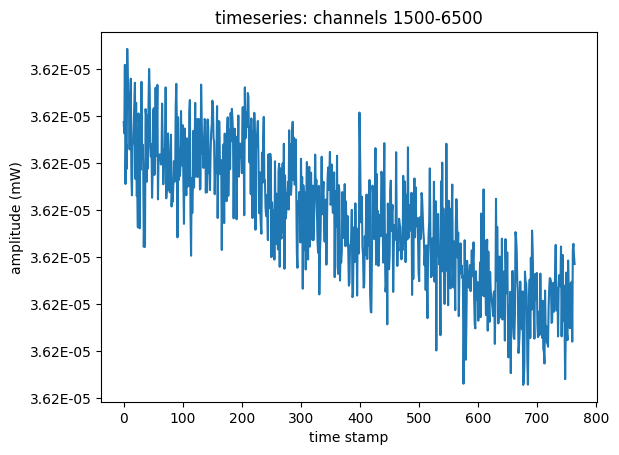

In [7]:
chani = 1500
chanf = 6500

plsp = np.sum(spec[:,chani:chanf+1],axis=1)/(chanf-chani+1)

plt.figure()
plt.title('timeseries: channels '+str(chani)+'-'+str(chanf))
plt.xlabel('time stamp')
plt.ylabel('amplitude (mW)')
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2E'))
plt.plot(plsp)
plt.show()

**Plot of autodifferences of data along 'time' axis averaged over a range of 'channels', and their histograms**

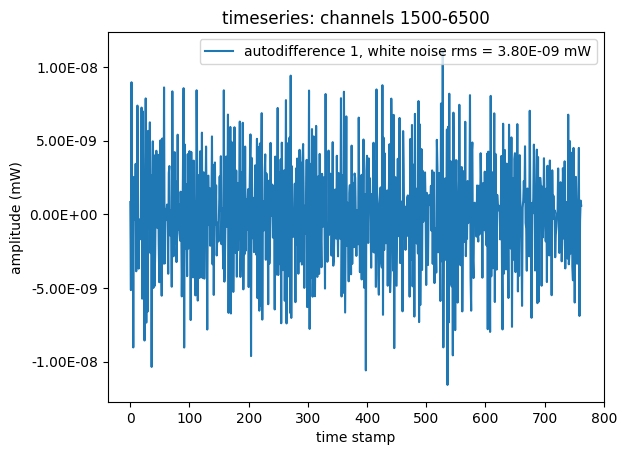

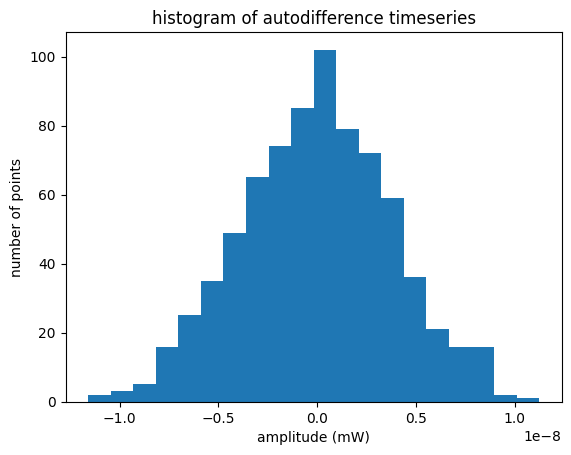

In [8]:
# autodifference of averaged timeseries

ad = (plsp[:-1]-plsp[1:])/np.sqrt(2)
wn = np.std(ad)

plt.figure()
plt.title('timeseries: channels '+str(chani)+'-'+str(chanf))
plt.xlabel('time stamp')
plt.ylabel('amplitude (mW)')
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2E'))
plt.plot(ad,label='autodifference 1, white noise rms = {:.2E} mW'.format(wn))
plt.legend()
plt.draw()

# histogram of autodifference - to check for gaussianity

plt.figure()
plt.title('histogram of autodifference timeseries')
plt.xlabel('amplitude (mW)')
plt.ylabel('number of points')
plt.hist(ad, bins='auto')
plt.draw()

plt.show()

**Power spectrum of data along 'time' axis averaged over a range of 'channels' fitted with a suitable power law, plotted against white noise level calculated from autodifference data**

/var/folders/_8/scf0b0g13g9f9vr2vtljc8480000gn/T/ipykernel_67304/1320710073.py:9: RuntimeWarning: invalid value encountered in power
  return c*(1+pow(fk/f,a))


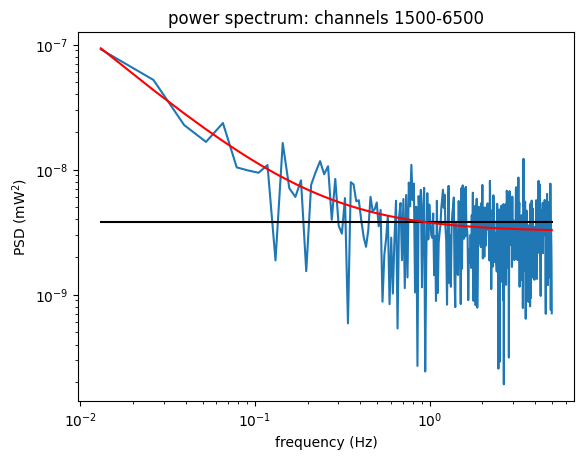

In [9]:
# power spectrum for the averaged channels

Psp = np.absolute(np.fft.rfft(plsp,norm='ortho'))[1:]
fsp = np.fft.rfftfreq(plsp.shape[0],ts)[1:]

# defining fitting function

def func(f,c,fk,a):
    return c*(1+pow(fk/f,a))

# Fitting to input averaged power spectrum

popt, pcov = curve_fit(func,fsp,Psp,p0=[1,1,1])

# Creating data to be plotted for white noise level determined using autodifferencing

wnpsd = pow(wn,2)*ts
ypsd = np.zeros(fsp.shape)
ypsd[:] = wn

# plot power spectrum for the averaged channels

plt.figure()
plt.title('power spectrum: channels '+str(chani)+'-'+str(chanf))
plt.xlabel('frequency (Hz)')
plt.ylabel('PSD (mW$^2$)')
plt.semilogx()
plt.semilogy()
plt.plot(fsp,Psp)
plt.plot(fsp,ypsd,'-k',label='PSD$_{wn}$ from autodifference')
plt.plot(fsp,func(fsp,*popt),'-r',label='{:.2E}(1+({:.2f}/f)^{:.2f})'.format(popt[0],popt[1],popt[2]))
plt.draw()

plt.show()